In [ ]:
from intersection2d_sim import Simulator
from pedestrian_agent import Agent, Agent2D
import numpy as np
from mm_mpc_inter2d import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent

k_max = 3
ev_noise_std=[0.01,0.01]
tv_noise_std=[0.2, 0.2]
ev=Agent2D(role='EV', dt=0.15, cl=11, state=np.array([2, 6.,0 ]), noise_std=ev_noise_std)
                    
agents=[Agent(role='TV', dt=0.15, cl=1, state=np.array([0, 8]), noise_std=tv_noise_std) for i in range(1)]
agents+=[Agent(role='TV', dt=0.15, cl=0, state=np.array([0, 8]), noise_std=tv_noise_std) for i in range(1)]
agents.append(Agent(role='ped', dt=0.15, cl=7, state=np.array([0., 3.]), noise_std=tv_noise_std, s_dec = 8))
                    
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=150, K_max=k_max)

N=10

Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[0.5, 0.0], [0.0, 10]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.15,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': False
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["MM-MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = algs[0]
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=True, robust_horizon=1, ref=None, num_clusters=k_max)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0
Doing SM-MPC with clusters: [[(0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 2, 0), (0, 2, 1), (0, 2, 2)], [(1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 2, 0), (1, 2, 1), (1, 2, 2)], [(0, 0, 0), (0, 0, 1), (0, 0, 2), (1, 0, 0), (1, 0, 1), (1, 0, 2), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 2, 0), (2, 2, 1), (2, 2, 2)]]
Scene modes: 3
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#constraints : 1820 and #decision_vars : 443
Agent 0 Solve Time: 2.855358123779297
v_des, dv, ds: 8.50682, 0.0, 100000.0
++++++++++++++++++
v_des, dv, ds: 8.50682, 0.0, 100000.0
++++++++++++++++++
Agent state:  [2.9 6. ]  Agent control:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Agent pos:  [ 23.5    -13.       1.5708]
TV pos:  [60.      15.       3.14159]
Ped pos:  [ 1. 26.  0.]
1
Doing SM-MPC with clusters: [[(0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 2, 0), (0, 2, 1), (0, 2, 2)], [(1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 2, 0), (1

KeyboardInterrupt: 

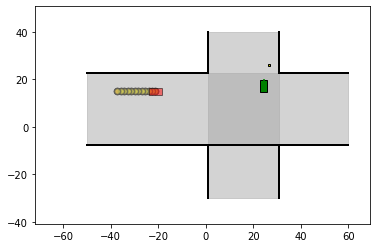

In [4]:
import matplotlib.pyplot as plt 
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())

In [ ]:

from mm_mpc_inter2d import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent


ev_noise_std=[0.01,0.01]
tv_noise_std=[0.1, 0.1]
ev=Agent2D(role='EV', dt=0.15, cl=3, state=np.array([40, 6.,0 ]), noise_std=ev_noise_std)
                    
agents=[Agent(role='TV', dt=0.15, cl=4, state=np.array([10, 0]), noise_std=tv_noise_std) for i in range(1)]
agents.append(Agent(role='ped', dt=0.1, cl=7, state=np.array([0., 3.]), noise_std=tv_noise_std, s_dec = 8))
                    
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=150)

N=11

Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[0.5, 0.0], [0.0, 10]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.15,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': False
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["SM-MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = algs[0]
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=True, robust_horizon=2, ref=None)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0
Doing SM-MPC
Scene modes: 2
Cluster 0 : [(0, 0), (0, 1), (0, 2)]
Cluster 1 : [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[ 0.      -9.77688 -8.82574 -7.83089 -6.79292 -5.71248 -4.59026 -3.42701
  -2.22353 -0.9807   0.30055  1.61921]
 [ 0.       0.       0.       0.       0.       0.       0.       0.
   0.       0.       0.       0.     ]]
TV PRED:  
[[50, 49.9663, 49.865, 49.6963, 49.46, 49.1563, 48.785, 48.3463, 47.84, 47.2663, 46.625, 45.9163], 
 [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]]
Dist : [61.59742 60.57725 59.45058 58.21848 56.88214 55.44293 53.90241 52.26239
 50.52492 48.69245 46.76781]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Agent 0 Solve Time: 1.5401926040649414
Vehicle #0 (EV: True):=   Keep Going
v_des, dv, ds: 7.09483, 0.0, 100000.0
++++++++++++++++++
Agent state:  [40.9  6. ]  Agent control:  [[0. 0. 0. 

Function solver_qpsol (0x270938f0)
Input 0 (h): all zero sparse: 243-by-243
Input 1 (g): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Input 2 (a): sparse: 453-by-243, 16701 nnz
 (1, 0) -> 0.15
 (2, 0) -> 0.15
 (3, 0) -> 0.15
 ...
 (411, 238) -> 3.1256
 (431, 238) -> 0
 (451, 238) -> 3.1256
Input 3 (lba): [-5.32255

Infeasible solve
Vehicle #0 (EV: True):=   Keep Going
v_des, dv, ds: 5.5, 0.0, 100000.0
++++++++++++++++++
Agent state:  [80.67846  3.57255]  Agent control:  [[-5. -5. -5. -5. -5. -5. -5. -5. -5. -5. -5.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
Agent pos:  [23.36956 13.02915  1.43902]
TV pos:  [26.12559 16.80029  2.43409]
Ped pos:  [ 9.61806 26.       0.     ]
46
Doing SM-MPC
Scene modes: 2
Cluster 0 : [(1, 0), (1, 1), (1, 2)]
Cluster 1 : [(0, 0), (0, 1), (0, 2), (2, 0), (2, 1), (2, 2)]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[ 0.      24.19118 24.20961 24.21698 24.21892 24.21989 24.22007 24.22007
  24.22007 24.22007 24.22007 24.22007]
 [ 0.      14.0523  14.4366  14.70334 14.85228 14.97527 15.15574 15.39906
  15.70539 16.07475 16.50718 17.00272]]
TV PRED:  
[[25.7251, 25.2959, 24.8792, 24.4889, 24.1401, 23.8498, 23.6358, 23.5177, 23.5, 23.5, 23.5, 23.5], 
 [17.1686, 17.6307, 18.166, 18.7781, 19.4687, 20.237, 21.0792

Function solver_qpsol (0x27c53900)
Input 0 (h): all zero sparse: 243-by-243
Input 1 (g): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Input 2 (a): sparse: 453-by-243, 16701 nnz
 (1, 0) -> 0.15
 (2, 0) -> 0.15
 (3, 0) -> 0.15
 ...
 (411, 238) -> 3.13482
 (431, 238) -> 0
 (451, 238) -> 3.13482
Input 3 (lba): [-4.572

Infeasible solve
Vehicle #0 (EV: True):=   Keep Going
v_des, dv, ds: 5.5, 0.0, 100000.0
++++++++++++++++++
Agent state:  [81.15809  2.82255]  Agent control:  [[-5. -5. -5. -5. -5. -5. -5. -5. -5. -5. -5.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
Agent pos:  [23.43587 13.6175   1.4785 ]
TV pos:  [25.72515 17.16859  2.36153]
Ped pos:  [ 9.79671 26.       0.     ]
47
Doing SM-MPC
Scene modes: 2
Cluster 0 : [(2, 0), (2, 1), (2, 2)]
Cluster 1 : [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[ 0.      24.20961 24.21698 24.21892 24.2199  24.22007 24.22007 24.22007
  24.22007 24.22007 24.22007 24.22007]
 [ 0.      14.4366  14.70334 14.85228 14.97672 15.16128 15.41152 15.72751
  16.10926 16.55679 17.07012 17.64926]]
TV PRED:  
[[25.3286, 24.9007, 24.5056, 24.1568, 23.8675, 23.6526, 23.5271, 23.5, 23.5, 23.5, 23.5, 23.5], 
 [17.5924, 18.1358, 18.7486, 19.4313, 20.1817, 20.9956, 21.8659,

...

Infeasible solve
v_des, dv, ds: 9.3161, 0.0, 100000.0
++++++++++++++++++
Agent state:  [81.09153 -0.05   ]  Agent control:  [[-5. -5. -5. -5. -5. -5. -5. -5. -5. -5. -5.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
Agent pos:  [23.47226 14.0929   1.51029]
TV pos:  [ 0.65243 15.       3.14159]
Ped pos:  [21.26505 26.       0.     ]
120
Doing SM-MPC
Scene modes: 2
Cluster 0 : [(0, 0), (0, 1), (0, 2)]
Cluster 1 : [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[ 0.      24.25326 24.25876 24.26777 24.27706 24.28328 24.28464 24.28464
  24.28464 24.28464 24.28464 24.28464]
 [ 0.      14.00605 14.10455 14.27399 14.51453 14.8262  15.1976  15.62888
  16.12767 16.69397 17.32777 18.02907]]
TV PRED:  
[[-0.658215, -2.07655, -3.4912, -4.90274, -6.31175, -7.7188, -9.12446, -10.5293, -11.9338, -13.3386, -14.7442, -16.1512], 
 [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]]
Dist : [26.34857 27.

Function solver_qpsol (0x278b90a0)
Input 0 (h): all zero sparse: 243-by-243
Input 1 (g): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Input 2 (a): sparse: 453-by-243, 16701 nnz
 (1, 0) -> 0.15
 (2, 0) -> 0.15
 (3, 0) -> 0.15
 ...
 (411, 238) -> 0.199289
 (431, 238) -> 0
 (451, 238) -> 0.199289
Input 3 (lba): [-0.9

Infeasible solve
v_des, dv, ds: 9.33398, 0.0, 100000.0
++++++++++++++++++
Agent state:  [81.02778 -0.05   ]  Agent control:  [[-5. -5. -5. -5. -5. -5. -5. -5. -5. -5. -5.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
Agent pos:  [23.46841 14.02927  1.50604]
TV pos:  [-0.65822 15.       3.14159]
Ped pos:  [21.2975 26.      0.    ]
121
Doing SM-MPC
Scene modes: 2
Cluster 0 : [(0, 0), (0, 1), (0, 2)]
Cluster 1 : [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[ 0.      24.24861 24.25502 24.26444 24.27466 24.28273 24.28464 24.28464
  24.28464 24.28464 24.28464 24.28464]
 [ 0.      13.93913 14.03757 14.20699 14.44749 14.75912 15.13384 15.56513
  16.06392 16.63021 17.26401 17.96532]]
TV PRED:  
[[-2.01344, -3.44101, -4.86344, -6.28135, -7.69531, -9.10592, -10.5138, -11.9194, -13.3233, -14.7262, -16.1286, -17.5309], 
 [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]]
Dist : [27.70993 29.1

Function solver_qpsol (0x25355840)
Input 0 (h): all zero sparse: 243-by-243
Input 1 (g): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Input 2 (a): sparse: 453-by-243, 16701 nnz
 (1, 0) -> 0.15
 (2, 0) -> 0.15
 (3, 0) -> 0.15
 ...
 (411, 238) -> 0.179314
 (431, 238) -> 0
 (451, 238) -> 0.179314
Input 3 (lba): [-0.9

Infeasible solve
v_des, dv, ds: 9.35246, 0.0, 100000.0
++++++++++++++++++
Agent state:  [80.96403 -0.05   ]  Agent control:  [[-5. -5. -5. -5. -5. -5. -5. -5. -5. -5. -5.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
Agent pos:  [23.46387 13.96568  1.50179]
TV pos:  [-2.01344 15.       3.14159]
Ped pos:  [21.36308 26.       0.     ]
122
Doing SM-MPC
Scene modes: 2
Cluster 0 : [(0, 0), (0, 1), (0, 2)]
Cluster 1 : [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[ 0.      24.24383 24.25085 24.26073 24.27201 24.2813  24.28464 24.28464
  24.28464 24.28464 24.28464 24.28464]
 [ 0.      13.87222 13.97062 14.14001 14.38045 14.69205 15.07009 15.50137
  16.00016 16.56646 17.20026 17.90156]]
TV PRED:  
[[-3.41655, -4.83172, -6.24514, -7.65739, -9.06902, -10.4806, -11.8926, -13.3057, -14.7204, -16.1371, -17.5565, -18.979], 
 [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]]
Dist : [29.09741 30

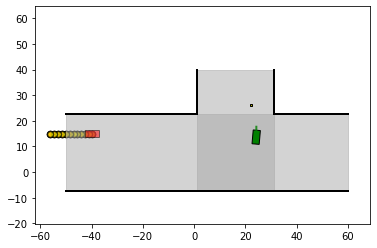

In [ ]:
import matplotlib.pyplot as plt 
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())

In [ ]:

from mm_mpc_inter2d import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent


ev_noise_std=[0.01,0.01]
tv_noise_std=[0.1, 0.1]
ev=Agent2D(role='EV', dt=0.15, cl=3, state=np.array([30, 6.,0 ]), noise_std=ev_noise_std)
                    
agents=[Agent(role='TV', dt=0.15, cl=1, state=np.array([0, 0]), noise_std=tv_noise_std) for i in range(1)]
agents.append(Agent(role='ped', dt=0.15, cl=7, state=np.array([0., 3.]), noise_std=tv_noise_std, s_dec = 8))
                    
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=150)

N=11

Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[0.5, 0.0], [0.0, 10]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.15,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': False
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["MM-MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = algs[0]
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=True, robust_horizon=2, ref=None)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0
Scene modes: 9
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EV PRED:  [[  0.      -19.60352 -18.64505 -17.6378  -16.58223 -15.47879 -14.32802
  -13.13045 -11.88669 -10.59739  -9.26325  -7.88503]
 [  0.        0.        0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.     ]]
TV PRED:  
[[60, 59.9663, 59.865, 59.6963, 59.46, 59.1563, 58.785, 58.3463, 57.84, 57.2663, 56.625, 55.9163], 
 [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]]
Dist : [80.97128 79.93014 78.77535 77.50755 76.12746 74.63587 73.03368 71.32188
 69.50161 67.57412 65.54085]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Agent 0 Solve Time: 0.9004819393157959
v_des, dv, ds: 8.50682, 0.0, 100000.0
++++++++++++++++++
Agent state:  [30.9  6. ]  Agent control:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Agent pos:  [-20.51282   0.        0.     ]
TV pos:  [60.     

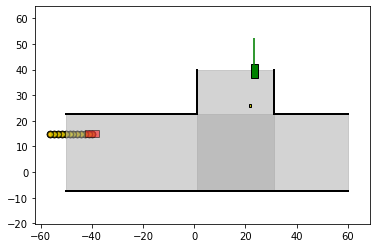

In [ ]:
import matplotlib.pyplot as plt 
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())

In [ ]:
# from intersection_sim import Simulator
# from pedestrian_agent import Agent
# from mm_mpc_inter import MM_MPC_TI
# # from uncontrolled_agent import UncontrolledAgent

# import numpy as np



# ev_noise_std=[0.0001,0.0001]
# ev=Agent(role='EV', state=np.array([50, 7.]), cl=3, noise_std=ev_noise_std)
# tv_noise_std=[0.1, 0.1]
# agents=[Agent(role='TV', cl=4, state=np.array([35, 0.]), noise_std=tv_noise_std) for i in range(1)]
# # agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# # agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

# tv_n_stds=[v.noise_std for v in agents]
# agents.append(ev)
# Sim=Simulator(agents, T_FINAL=50)

# N=10

# # Sim.T+=10
# Sim.set_MPC_N(N)

# initial_states = [[0.0, 2.0]]
# final_states = [[100.0, 4.0]]



# cost_func_params = {
#     'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
#     'R': np.array([[.75, 0.0], [0.0, .5]]),
#     'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
#     'Qc': 8,
#     'kappa': 3 
# }
# mpc_params = {
#     'num_agents': 1,
#     'dt': 0.2,
#     'N' : N,
#     'rob_dia': 0.3,
#     'v_lim': 8.0,
#     'omega_lim': 1.0,
#     'total_sim_timestep': 200,
#     'obs_sim_timestep': 100,
#     'epsilon_o': 0.05,
#     'epsilon_r': 0.05,
#     'safety_margin': 0.05,
#     'goal_tolerence': 0.2, 
#     'linearized_ca': True
# }
# obs_traj = []
# static_obs = []

# obs = {"static": static_obs, "dynamic": obs_traj}

# num_trials = 1
# algs = ["MPC"]
# vel_var_levels = [0.05, 0.4]
# rationality = 0.5
# T = 6
# y_pos = 3

# scenario = "test"
# trial = 1
# uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
# uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=False, robust_horizon=2, ref=None)
# # mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
# mpc.simulate(Sim)

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.transforms as tf
# from celluloid import Camera
# from IPython.display import HTML
# import pdb

# fig, ax= plt.subplots()
# camera = Camera(fig)

# for  i in range(Sim.t):
#     Sim.draw_intersection(ax, i)
#     camera.snap()

# animation = camera.animate(repeat = True, repeat_delay = 100)
# HTML(animation.to_html5_video())